# NewsBot 2.0 Final Project

**ITAI 2373 - Final Project**  
**Student:** Viktoriya Kurmisheva  
**Foundation:** Midterm NewsBot Intelligence System  
**Peer Review Format:** Team Testers with Abraham Barreto

This notebook transforms the midterm NewsBot into a more advanced news analysis platform. It keeps the working midterm foundation and adds final-project modules for topic modeling, summarization, semantic search, multilingual processing, conversational queries, and an advanced research extension.

The notebook uses free/open-source tools only. No paid API keys are required.

## 1. Environment Setup and Imports

This section installs or loads the libraries needed for the final system. The code uses free tools that work in Google Colab: pandas, scikit-learn, NLTK, spaCy, NetworkX, and optional Gradio.

In [2]:
# Core utilities for checking and installing packages in Colab
import sys
import subprocess
import importlib.util
from pathlib import Path


def package_available(import_name):
    """Return True if a Python package is already available."""
    return importlib.util.find_spec(import_name) is not None


def install_if_missing(import_name, pip_name=None):
    """Install a package only if the notebook environment does not already have it."""
    if not package_available(import_name):
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            pip_name or import_name
        ])


# Most Colab runtimes already include many of these packages.
# This loop keeps the notebook portable without forcing unnecessary installs.
for import_name, pip_name in [
    ("pandas", "pandas"),
    ("numpy", "numpy"),
    ("sklearn", "scikit-learn"),
    ("nltk", "nltk"),
    ("spacy", "spacy"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("networkx", "networkx"),
    ("langdetect", "langdetect"),
    ("wordcloud", "wordcloud"),
    ("gradio", "gradio"),
    ("IPython", "ipython"),
]:
    install_if_missing(import_name, pip_name)


# General Python libraries
import os
import re
import math
import json
import zipfile
import random
import warnings
from collections import Counter, defaultdict
from itertools import combinations

# Data analysis and visualization libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from IPython.display import display

# NLTK tools for preprocessing and sentiment analysis
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer

# spaCy tools for named entity recognition and dependency parsing
import spacy
from spacy.language import Language

# Language detection for the multilingual module
from langdetect import detect, DetectorFactory

# Machine learning and text modeling tools
from scipy.sparse import csr_matrix, hstack
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity


# Keep notebook output cleaner and make model behavior more repeatable.
warnings.filterwarnings("ignore")
DetectorFactory.seed = 42
random.seed(42)
np.random.seed(42)


# Download required NLTK resources.
# These are needed for tokenization, stop words, lemmatization, and VADER sentiment.
for resource in [
    "punkt",
    "punkt_tab",
    "stopwords",
    "wordnet",
    "omw-1.4",
    "vader_lexicon",
]:
    try:
        nltk.download(resource, quiet=True)
    except Exception:
        pass


# Load the small English spaCy model.
# If Colab does not have it yet, download it automatically.
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    subprocess.check_call([
        sys.executable,
        "-m",
        "spacy",
        "download",
        "en_core_web_sm"
    ])
    nlp = spacy.load("en_core_web_sm")


print("Environment ready.")

Environment ready.


## 2. Configuration and Data Loading

The final project builds on the same BBC News Classification data used in the midterm. The dataset has substantial English articles, clear category labels, and more than 500 rows across five categories.

If this notebook runs in Colab, upload `learn-ai-bbc.zip` when prompted. If the file already exists in the notebook folder, the loader uses it automatically.

In [3]:
# Imports needed for loading files and reading the dataset
from pathlib import Path
import zipfile
import pandas as pd


class NewsBot2Config:
    """Central configuration for NewsBot 2.0."""

    def __init__(self):
        # Basic project settings
        self.project_name = "NewsBot 2.0"
        self.random_state = 42

        # Dataset limits for Google Colab performance
        self.max_articles = 2000
        self.min_article_chars = 200

        # Feature/model settings
        self.tfidf_features = 5000
        self.topic_features = 4000
        self.topic_count = 8

        # Limits for slower NLP tasks such as entity extraction
        self.entity_article_limit = 700
        self.default_summary_sentences = 3


config = NewsBot2Config()


def running_in_colab():
    """Detect whether the notebook is running in Google Colab."""
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False


def locate_or_upload_bbc_zip():
    """Find the BBC dataset ZIP or ask the user to upload it in Colab."""
    candidates = [
        Path("learn-ai-bbc.zip"),
        Path("/content/learn-ai-bbc.zip"),
        Path.home() / "Downloads" / "learn-ai-bbc.zip",
        Path(r"C:\Users\Admin\Downloads\learn-ai-bbc.zip"),
    ]

    # Return the first matching ZIP file found.
    for candidate in candidates:
        if candidate.exists():
            return candidate

    # If running in Colab and no file is found, ask the user to upload it.
    if running_in_colab():
        from google.colab import files

        print("Upload learn-ai-bbc.zip from your computer.")
        uploaded = files.upload()

        for name in uploaded:
            if name.lower().endswith(".zip"):
                return Path(name)

    raise FileNotFoundError(
        "Could not find learn-ai-bbc.zip. Upload it or place it in the notebook folder."
    )


def load_bbc_dataset():
    """Load, clean, standardize, and validate the BBC News Classification dataset."""

    # Create a folder for the extracted dataset files.
    data_dir = Path("bbc_final_data")
    data_dir.mkdir(exist_ok=True)

    # Find or upload the ZIP file, then extract it.
    zip_path = locate_or_upload_bbc_zip()
    with zipfile.ZipFile(zip_path) as archive:
        archive.extractall(data_dir)

    # Find the training CSV inside the extracted files.
    csv_candidates = list(data_dir.rglob("BBC News Train.csv")) + list(data_dir.rglob("*Train*.csv"))

    if not csv_candidates:
        raise FileNotFoundError("Could not find the BBC training CSV after extracting the ZIP.")

    # Load the CSV and rename columns into a consistent project format.
    raw_df = pd.read_csv(csv_candidates[0])
    df = raw_df.rename(
        columns={"ArticleId": "article_id", "Text": "content", "Category": "category"}
    )[["article_id", "content", "category"]].copy()

    # Clean basic text/category fields and remove empty values.
    df["content"] = df["content"].fillna("").astype(str).str.strip()
    df["category"] = df["category"].fillna("").astype(str).str.strip()

    # Create a simple title from the first part of the article text.
    df["title"] = (
        df["content"]
        .str.split(r"\s{2,}|\n", n=1)
        .str[0]
        .str.split()
        .str[:16]
        .str.join(" ")
        .str.title()
    )

    df["source"] = "BBC News Classification (Kaggle)"

    # The BBC file does not include publication dates.
    # These generated dates support trend demos only.
    df["analysis_date"] = pd.date_range("2024-01-01", periods=len(df), freq="D")
    df["analysis_month"] = df["analysis_date"].dt.to_period("M").astype(str)

    # Keep only substantial articles with valid categories.
    df = df[
        (df["content"].str.len() >= config.min_article_chars)
        & (df["category"].str.len() > 0)
    ].copy()

    # Limit the dataset size if needed so it stays Colab-friendly.
    if len(df) > config.max_articles:
        df = df.sample(n=config.max_articles, random_state=config.random_state).copy()

    # Confirm that the dataset meets the assignment requirements.
    requirements = {
        "At least 500 articles": len(df) >= 500,
        "At least 4 categories": df["category"].nunique() >= 4,
        "At most 2,000 articles": len(df) <= 2000,
        "No missing content": df["content"].notna().all() and df["content"].str.len().gt(0).all(),
        "No missing category": df["category"].notna().all() and df["category"].str.len().gt(0).all(),
        "Substantial article text": df["content"].str.len().ge(config.min_article_chars).all(),
    }

    display(pd.DataFrame({"Requirement": requirements.keys(), "Passed": requirements.values()}))

    assert all(requirements.values()), "Dataset validation failed."

    return df.reset_index(drop=True)


df = load_bbc_dataset()

print(f"Loaded {len(df)} articles across {df['category'].nunique()} categories.")
display(df.head())

Upload learn-ai-bbc.zip from your computer.


Saving learn-ai-bbc (1).zip to learn-ai-bbc (1).zip


,Requirement,Passed
0,At least 500 articles,True
1,At least 4 categories,True
2,"At most 2,000 articles",True
3,No missing content,True
4,No missing category,True
5,Substantial article text,True


Loaded 1490 articles across 5 categories.


,article_id,content,category,title,source,analysis_date,analysis_month
0,1833,worldcom ex-boss launches defence lawyers defe...,business,Worldcom Ex-Boss Launches Defence Lawyers Defe...,BBC News Classification (Kaggle),2024-01-01,2024-01
1,154,german business confidence slides german busin...,business,German Business Confidence Slides German Busin...,BBC News Classification (Kaggle),2024-01-02,2024-01
2,1101,bbc poll indicates economic gloom citizens in ...,business,Bbc Poll Indicates Economic Gloom Citizens In ...,BBC News Classification (Kaggle),2024-01-03,2024-01
3,1976,lifestyle governs mobile choice faster bett...,tech,Lifestyle,BBC News Classification (Kaggle),2024-01-04,2024-01
4,917,enron bosses in $168m payout eighteen former e...,business,Enron Bosses In $168M Payout Eighteen Former E...,BBC News Classification (Kaggle),2024-01-05,2024-01


## 3. Enhanced Preprocessing Pipeline

This section keeps the midterm cleaning logic but wraps it into a reusable class. The final system uses the same preprocessing across classification, topic modeling, semantic search, and summarization.

In [4]:
class TextPreprocessor:
    """Clean and normalize raw news text for NLP modeling."""

    def __init__(self):
      # Create tools used during preprocessing.
        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words("english"))

    def clean_text(self, text):
        """Remove URLs, HTML, email addresses, symbols, digits, and extra spacing."""
        if pd.isna(text):
            return ""

        # Convert everything to lowercase so words match more consistently.
        text = str(text).lower()

        # Remove common noise that does not help the NLP models.
        text = re.sub(r"<[^>]+>", " ", text)
        text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
        text = re.sub(r"\S+@\S+", " ", text)

        # Keep only letters and spaces, then normalize extra whitespace.
        text = re.sub(r"[^a-zA-Z\s]", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text

    def tokenize(self, text):
        """Tokenize with a lightweight regex so the pipeline remains stable in Colab."""
        return re.findall(r"[a-z]+", text.lower())

    def preprocess(self, text, remove_stopwords=True, lemmatize=True):
        """Run the full preprocessing pipeline and return processed text."""

        # Clean the text before splitting it into tokens.
        cleaned = self.clean_text(text)
        tokens = self.tokenize(cleaned)

        # Remove common words like "the" and "is" when requested.
        if remove_stopwords:
            tokens = [token for token in tokens if token not in self.stop_words]

        # Lemmatize words so related forms are treated more similarly.
        if lemmatize:
            tokens = [self.lemmatizer.lemmatize(token) for token in tokens]

        # Remove very short tokens that usually add noise.
        tokens = [token for token in tokens if len(token) > 2]
        return " ".join(tokens)


preprocessor = TextPreprocessor()

# Combine title and content so later models can use the full article context.
df["full_text"] = df["title"] + " " + df["content"]

# Store clean and processed versions for later NLP steps.
df["content_clean"] = df["content"].apply(preprocessor.clean_text)
df["content_processed"] = df["content"].apply(preprocessor.preprocess)
df["full_text_processed"] = df["full_text"].apply(preprocessor.preprocess)

# Add simple length features for exploration and classification.
df["word_count"] = df["content"].str.split().str.len()
df["char_count"] = df["content"].str.len()

print("Preprocessing complete.")
display(df[["article_id", "category", "title", "word_count", "content_processed"]].head())

Preprocessing complete.


,article_id,category,title,word_count,content_processed
0,1833,business,Worldcom Ex-Boss Launches Defence Lawyers Defe...,301,worldcom bos launch defence lawyer defending f...
1,154,business,German Business Confidence Slides German Busin...,325,german business confidence slide german busine...
2,1101,business,Bbc Poll Indicates Economic Gloom Citizens In ...,514,bbc poll indicates economic gloom citizen majo...
3,1976,tech,Lifestyle,634,lifestyle governs mobile choice faster better ...
4,917,business,Enron Bosses In $168M Payout Eighteen Former E...,355,enron boss payout eighteen former enron direct...


## 4. Advanced Content Analysis Engine

This required final-project module improves the midterm classifier with confidence scores, probability distributions, cross-validation, and explanation-ready feature names.

Training ComplementNB...
Training LogisticRegression...
Training LinearSVC...
Classifier comparison:


,Model,Test Accuracy,CV Mean,CV Std
1,LogisticRegression,0.9799,0.9681,0.0117
2,LinearSVC,0.9799,0.9690,0.0109
0,ComplementNB,0.9765,0.9656,0.0092



Production model evaluation:
               precision    recall  f1-score   support

     business       0.97      0.99      0.98        67
entertainment       1.00      0.98      0.99        55
     politics       0.98      0.96      0.97        55
        sport       0.99      1.00      0.99        69
         tech       0.96      0.96      0.96        52

     accuracy                           0.98       298
    macro avg       0.98      0.98      0.98       298
 weighted avg       0.98      0.98      0.98       298



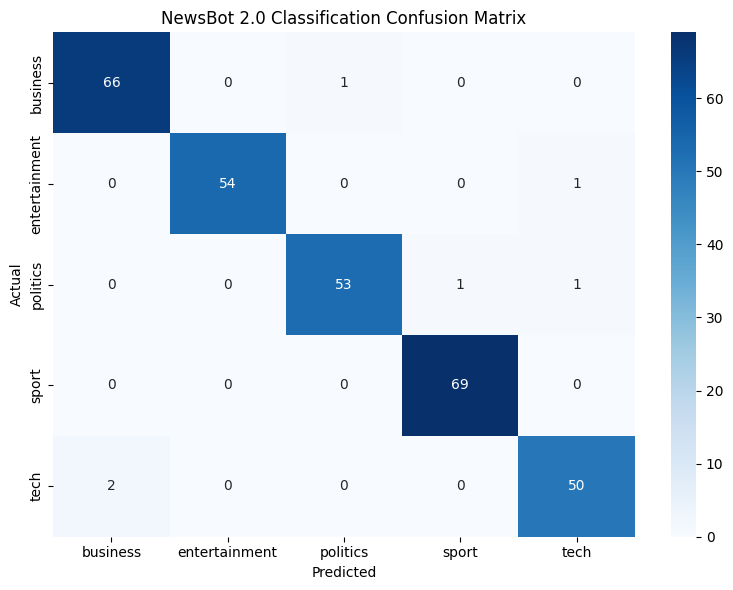

In [5]:
class AdvancedNewsClassifier:
    """Enhanced news classifier with confidence scoring and model comparison."""

    def __init__(self, max_features=8000, random_state=42):
      # Store model settings so the classifier stays consistent and repeatable.
        self.max_features = max_features
        self.random_state = random_state

      # TF-IDF converts processed article text into numerical features.
      # Bigrams help the model learn phrases like "stock market" or "prime minister."
        self.vectorizer = TfidfVectorizer(
            max_features=max_features,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.85,
            sublinear_tf=True,
        )

      # Logistic Regression is used as the main production model.
      # It gives probabilities and feature weights, which helps with explainability.
        self.model = OneVsRestClassifier(
            LogisticRegression(
                max_iter=1000,
                solver="liblinear",
                C=4.0,
                class_weight="balanced",
                random_state=random_state,
            ),
            n_jobs=1,
        )
        self.feature_names_ = None
        self.results_ = None

    def _extra_features(self, texts):
        """Create non-negative sentiment and length features for classification."""

        # VADER adds sentiment signals that TF-IDF alone may not capture.
        sia = SentimentIntensityAnalyzer()
        rows = []

        for text in texts:
            text = "" if pd.isna(text) else str(text)

            # Limit very long text for faster sentiment scoring.
            scores = sia.polarity_scores(text[:5000])

            # Use safe minimums to avoid division by zero.
            word_count = max(len(text.split()), 1)
            char_count = max(len(text), 1)

            # All features are kept non-negative so they work with Naive Bayes too.
            rows.append([
                (scores["compound"] + 1) / 2,
                scores["pos"],
                scores["neu"],
                scores["neg"],
                min(word_count / 1000, 1),
                min(char_count / 7000, 1),
            ])
        return np.array(rows, dtype=float)

    def _build_matrix(self, texts, fit=False):
        """Combine TF-IDF features with sentiment and length features."""

        # Fit the vectorizer during training; reuse it during prediction.
        if fit:
            text_matrix = self.vectorizer.fit_transform(texts)

            # Save feature names so prediction explanations can show readable labels.
            self.feature_names_ = list(self.vectorizer.get_feature_names_out()) + [
                "compound_sentiment_scaled",
                "positive_score",
                "neutral_score",
                "negative_score",
                "word_count_scaled",
                "char_count_scaled",
            ]
        else:
            text_matrix = self.vectorizer.transform(texts)

        # Add sentiment and length features to the TF-IDF matrix.
        extra_matrix = csr_matrix(self._extra_features(texts))

        return hstack([text_matrix, extra_matrix]).tocsr().copy()

    def fit(self, texts, labels):
        """Train the enhanced classifier and compare multiple algorithms."""

        # Build the full feature matrix and target labels.
        X = self._build_matrix(texts, fit=True)
        y = np.array(labels)

        # Use a stratified split so every category stays represented in train/test data.
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=self.random_state, stratify=y
        )

        # Compare several Colab-friendly text classification models.
        classifiers = {
            "ComplementNB": ComplementNB(alpha=0.5),
            "LogisticRegression": self.model,
            "LinearSVC": LinearSVC(random_state=self.random_state, C=1.0, class_weight="balanced"),
        }

        results = []
        fitted = {}

        for name, clf in classifiers.items():
            print(f"Training {name}...")

            # Train the model and evaluate it on the test split.
            clf.fit(X_train, y_train)
            predictions = clf.predict(X_test)

            # Cross-validation gives a second performance estimate.
            cv_scores = cross_val_score(clf, X_train, y_train, cv=2, scoring="accuracy")

            results.append({
                "Model": name,
                "Test Accuracy": accuracy_score(y_test, predictions),
                "CV Mean": cv_scores.mean(),
                "CV Std": cv_scores.std(),
            })
            fitted[name] = clf

        # Store model comparison results for reporting.
        self.results_ = pd.DataFrame(results).sort_values("Test Accuracy", ascending=False)

        # Keep Logistic Regression as the production model because it provides probabilities and explanations.
        self.model = fitted["LogisticRegression"]
        self.X_test_ = X_test
        self.y_test_ = y_test
        self.test_predictions_ = self.model.predict(X_test)
        return self

    def predict_proba(self, texts):
        """Return class probabilities for one or more texts."""
        X = self._build_matrix(list(texts), fit=False)
        return self.model.predict_proba(X)

    def predict_article(self, title, content):
        """Predict category, confidence, and class probabilities for one article."""

        # Combine title and content into one input string.
        text = f"{title} {content}".strip()

        probabilities = self.predict_proba([text])[0]
        classes = self.model.classes_

        # Select the category with the highest probability.
        best_idx = int(np.argmax(probabilities))
        confidence = float(probabilities[best_idx])

        # Convert the probability into an easy-to-read confidence label.
        if confidence >= 0.70:
            confidence_label = "high"
        elif confidence >= 0.45:
            confidence_label = "medium"
        else:
            confidence_label = "low"
        return {
            "predicted_category": classes[best_idx],
            "confidence": confidence,
            "confidence_label": confidence_label,
            "category_probabilities": dict(zip(classes, probabilities.round(4))),
        }

    def explain_prediction(self, title, content, top_n=8):
        """Explain a Logistic Regression prediction using the strongest feature contributions."""

        text = f"{title} {content}".strip()
        X = self._build_matrix([text], fit=False)

        prediction = self.model.predict(X)[0]
        class_index = list(self.model.classes_).index(prediction)

        # Get coefficients from either Logistic Regression or the One-vs-Rest wrapper.
        if hasattr(self.model, "coef_"):
            coefficients = self.model.coef_[class_index]
        elif hasattr(self.model, "estimators_"):
            coefficients = self.model.estimators_[class_index].coef_[0]
        else:
            return pd.DataFrame({"feature": ["Explanation unavailable"], "contribution": [0.0]})

        # Multiply feature values by model weights to estimate feature contribution.
        contributions = X.multiply(coefficients).toarray().ravel()
        top_indices = np.argsort(contributions)[-top_n:][::-1]

        return pd.DataFrame({
            "feature": [self.feature_names_[i] for i in top_indices if i < len(self.feature_names_)],
            "contribution": [contributions[i] for i in top_indices if i < len(self.feature_names_)],
        })

# Train the advanced classifier using the processed article text and category labels.
classifier = AdvancedNewsClassifier(max_features=config.tfidf_features, random_state=config.random_state)
classifier.fit(df["full_text_processed"], df["category"])

print("Classifier comparison:")
display(classifier.results_.round(4))

print("\nProduction model evaluation:")
print(classification_report(classifier.y_test_, classifier.test_predictions_))

# Visualize where the classifier performs well and where it confuses categories.
cm = confusion_matrix(classifier.y_test_, classifier.test_predictions_, labels=classifier.model.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classifier.model.classes_, yticklabels=classifier.model.classes_)
plt.title("NewsBot 2.0 Classification Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 5. Topic Modeling and Content Discovery

The final project requires topic discovery. This section implements both LDA and NMF so the system can discover hidden themes beyond the original category labels.

NMF topic words:


,topic_id,top_words
0,0,"mobile, phone, technology, gadget, people, dig..."
1,1,"labour, election, blair, party, tory, brown, t..."
2,2,"film, award, best, oscar, actor, star, actress..."
3,3,"game, england, win, player, match, team, wale,..."
4,4,"growth, rate, economy, economic, dollar, price..."
5,5,"said, company, firm, share, yukos, government,..."
6,6,"band, music, chart, album, single, song, numbe..."
7,7,"virus, mail, software, user, microsoft, progra..."


LDA topic words:


,topic_id,top_words
0,0,"said, election, labour, party, government, bla..."
1,1,"world, year, said, time, olympic, woman, champ..."
2,2,"game, said, england, player, win, time, year, ..."
3,3,"best, year, award, said, star, game, new, musi..."
4,4,"said, government, law, country, year, new, cou..."
5,5,"said, people, net, user, service, software, ma..."
6,6,"film, said, mobile, people, phone, technology,..."
7,7,"said, year, market, company, growth, sale, fir..."


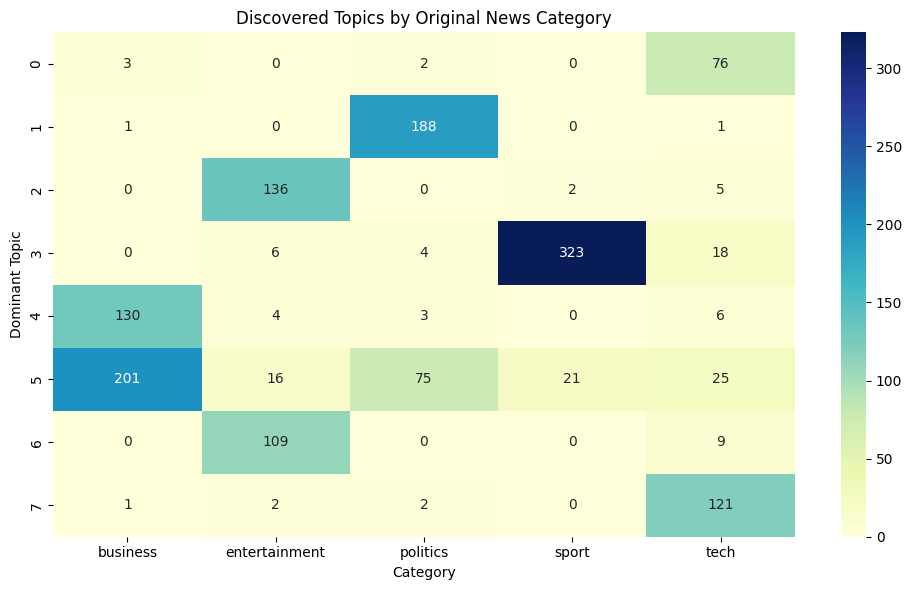

In [6]:
class TopicDiscoveryEngine:
    """Discover hidden topics using LDA and NMF."""

    def __init__(self, n_topics=8, max_features=5000, random_state=42):

        # Store topic modeling settings.
        self.n_topics = n_topics
        self.random_state = random_state

        self.count_vectorizer = CountVectorizer(max_features=max_features, min_df=2, max_df=0.85, stop_words="english")
        self.tfidf_vectorizer = TfidfVectorizer(max_features=max_features, min_df=2, max_df=0.85, stop_words="english")
        self.lda_model = LatentDirichletAllocation(n_components=n_topics, random_state=random_state, learning_method="batch")
        self.nmf_model = NMF(n_components=n_topics, random_state=random_state, init="nndsvda", max_iter=500)

    def fit(self, documents):
        """Train LDA and NMF topic models."""

        # Store the documents so the fitted engine can be inspected later.
        self.documents_ = list(documents)

        # Build the feature matrices needed by each topic model.
        self.count_matrix_ = self.count_vectorizer.fit_transform(self.documents_)
        self.tfidf_matrix_ = self.tfidf_vectorizer.fit_transform(self.documents_)

        # Fit both topic models and store each article's topic distribution.
        self.lda_topics_ = self.lda_model.fit_transform(self.count_matrix_)
        self.nmf_topics_ = self.nmf_model.fit_transform(self.tfidf_matrix_)

        return self

    def get_topic_words(self, method="nmf", n_words=10):
        """Return the top words for each topic."""

        # Select the correct model and vocabulary based on the requested method.
        if method == "lda":
            model = self.lda_model
            feature_names = self.count_vectorizer.get_feature_names_out()
        else:
            model = self.nmf_model
            feature_names = self.tfidf_vectorizer.get_feature_names_out()

        topic_rows = []

        # For each topic, find the words with the highest model weights.
        for topic_id, weights in enumerate(model.components_):
            top_indices = weights.argsort()[-n_words:][::-1]
            words = [feature_names[i] for i in top_indices]

            topic_rows.append({"topic_id": topic_id, "top_words": ", ".join(words)})

        return pd.DataFrame(topic_rows)

    def transform_new_text(self, text):
        """Assign a dominant NMF topic to new text."""

        # Preprocess the new article the same way as the training articles.
        processed = preprocessor.preprocess(text)

        # Transform the text into the fitted TF-IDF space.
        vector = self.tfidf_vectorizer.transform([processed])

        # Use NMF to estimate the topic distribution for the new text.
        distribution = self.nmf_model.transform(vector)[0]
        topic_id = int(np.argmax(distribution))

        return {"dominant_topic": topic_id, "topic_strength": float(distribution[topic_id])}

# Train the topic engine using the processed article content.
topic_engine = TopicDiscoveryEngine(
    n_topics=config.topic_count,
    max_features=config.topic_features,
    random_state=config.random_state,
)
topic_engine.fit(df["content_processed"])

# Assign each article to its strongest NMF topic.
df["dominant_topic"] = np.argmax(topic_engine.nmf_topics_, axis=1)

print("NMF topic words:")
display(topic_engine.get_topic_words("nmf", n_words=10))

print("LDA topic words:")
display(topic_engine.get_topic_words("lda", n_words=10))

# Compare discovered topics with the original BBC category labels.
topic_category = pd.crosstab(df["dominant_topic"], df["category"])

plt.figure(figsize=(10, 6))
sns.heatmap(topic_category, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Discovered Topics by Original News Category")
plt.xlabel("Category")
plt.ylabel("Dominant Topic")
plt.tight_layout()
plt.show()

## 6. Advanced Sentiment Evolution Analysis

This section extends the midterm sentiment work by tracking sentiment across categories and generated analysis months. The BBC dataset does not provide verified publication dates, so `analysis_month` supports trend demonstration only.

Sentiment by category:


,avg_sentiment,sentiment_std,positive_rate,negative_rate
category,,,,
business,0.2312,0.8450,0.6161,0.3750
entertainment,0.5920,0.6960,0.8059,0.1941
politics,0.0376,0.8833,0.5073,0.4854
sport,0.5493,0.7352,0.7803,0.2110
tech,0.5153,0.7651,0.7701,0.2261


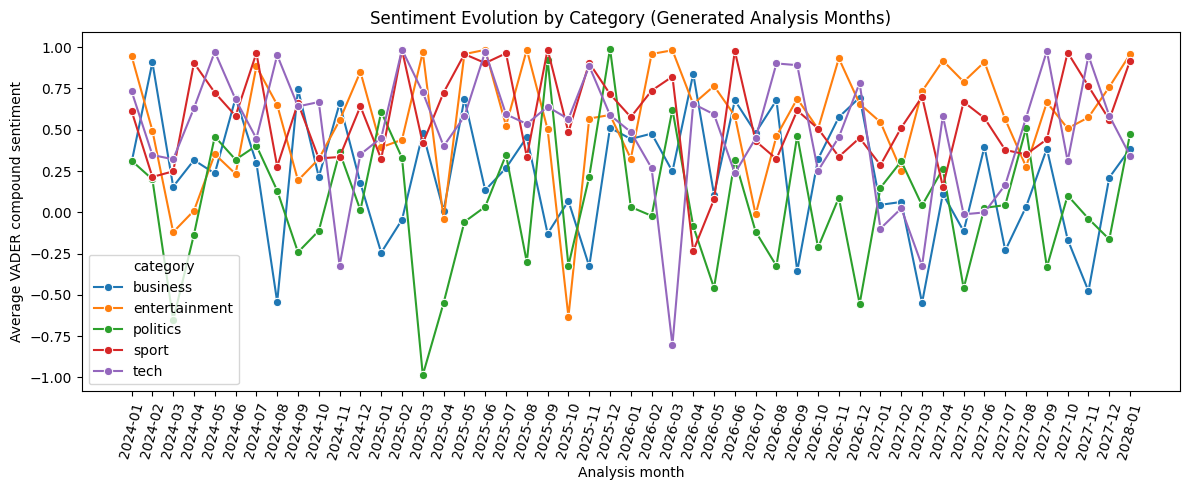

In [7]:
class SentimentEvolutionTracker:
    """Analyze article sentiment and track changes over categories and time periods."""

    def __init__(self):
        # VADER works well for quick rule-based sentiment scoring.
        self.sia = SentimentIntensityAnalyzer()

    def analyze_text(self, text):
        """Return VADER sentiment scores and a readable label."""

        # Convert missing values to empty text so sentiment analysis does not fail.
        scores = self.sia.polarity_scores("" if pd.isna(text) else str(text))

        # Use standard VADER thresholds for positive, negative, and neutral labels.
        if scores["compound"] >= 0.05:
            label = "positive"
        elif scores["compound"] <= -0.05:
            label = "negative"
        else:
            label = "neutral"
        return {**scores, "sentiment_label": label}

    def transform_dataset(self, frame, text_col="full_text"):
        """Add sentiment columns to the dataset."""
        rows = []

        # Analyze each article and keep the fields needed for summaries and trends.
        for _, row in frame.iterrows():
            scores = self.analyze_text(row[text_col])

            rows.append({
                "article_id": row["article_id"],
                "category": row["category"],
                "analysis_month": row["analysis_month"],
                "compound": scores["compound"],
                "positive": scores["pos"],
                "neutral": scores["neu"],
                "negative": scores["neg"],
                "sentiment_label": scores["sentiment_label"],
            })

        self.sentiment_df_ = pd.DataFrame(rows)

        return self.sentiment_df_

    def category_summary(self):
        """Summarize sentiment by category."""

        # Average sentiment shows tone, while positive/negative rates show label patterns.
        return self.sentiment_df_.groupby("category").agg(
            avg_sentiment=("compound", "mean"),
            sentiment_std=("compound", "std"),
            positive_rate=("sentiment_label", lambda x: (x == "positive").mean()),
            negative_rate=("sentiment_label", lambda x: (x == "negative").mean()),
        ).round(4)


# Run sentiment analysis on the full dataset.
sentiment_tracker = SentimentEvolutionTracker()
sentiment_df = sentiment_tracker.transform_dataset(df)

print("Sentiment by category:")
display(sentiment_tracker.category_summary())

# Track average sentiment by generated analysis month and category.
trend_df = sentiment_df.groupby(["analysis_month", "category"], as_index=False)["compound"].mean()
plt.figure(figsize=(12, 5))

sns.lineplot(data=trend_df, x="analysis_month", y="compound", hue="category", marker="o")
plt.title("Sentiment Evolution by Category (Generated Analysis Months)")
plt.xlabel("Analysis month")
plt.ylabel("Average VADER compound sentiment")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

## 7. Entity Relationship Mapping

This section expands the midterm NER work by mapping entity co-occurrences. This helps reveal which people, organizations, locations, and events appear together in news coverage.

Entities extracted: 14095 from first 700 articles


,text,label,category
0,Worldcom Ex-Boss Launches Defence Lawyers Defe...,ORG,business
1,Bernie Ebbers,PERSON,business
2,cynthia cooper,PERSON,business
3,us,GPE,business
4,2002,DATE,business
5,5.7bn,MONEY,business
6,new york,GPE,business
7,wednesday,DATE,business
8,arthur andersen,PERSON,business
9,early 2001 and,DATE,business


Top entity types:


,mentions
label,
DATE,4179
PERSON,3994
GPE,2544
ORG,2396
MONEY,904
PRODUCT,45
EVENT,33


Top entity relationships:


,entity_1,entity_2,co_mentions
0,britain,uk,18
1,uk,us,18
2,bbc,britain,15
3,blair,britain,14
4,france,germany,13
5,london,uk,13
6,france,italy,12
7,britain,tony blair,12
8,blair,tony blair,12
9,britain,gordon brown,11


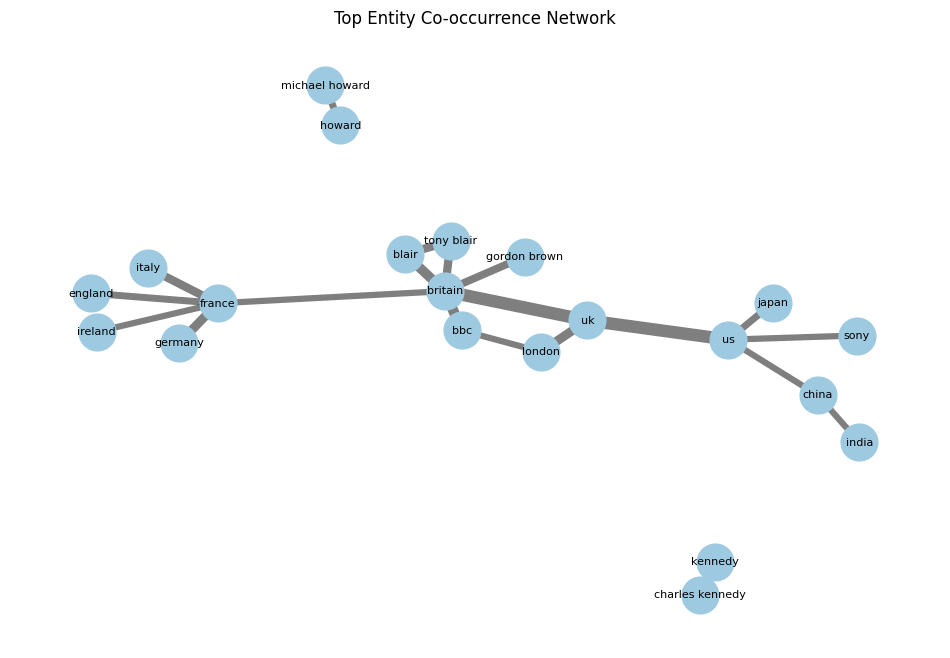

In [8]:
class EntityRelationshipMapper:
    """Extract named entities and build co-occurrence relationships."""

    def __init__(self, nlp_model, allowed_labels=None):
        self.nlp = nlp_model

        # Limit entities to labels that are useful for news analysis.
        self.allowed_labels = allowed_labels or {"PERSON", "ORG", "GPE", "DATE", "MONEY", "PRODUCT", "EVENT"}

    def extract_from_doc(self, text):
        """Extract named entities from one text."""

        # Limit text length to keep entity extraction fast in Colab.
        doc = self.nlp(str(text)[:5000])
        entities = []

        for ent in doc.ents:
            # Keep only useful entity types and skip tiny/noisy entities.
            if ent.label_ in self.allowed_labels and len(ent.text.strip()) > 1:
                entities.append({
                    "text": ent.text.strip(),
                    "label": ent.label_,
                    "description": spacy.explain(ent.label_) or ent.label_,
                })

        return entities

    def fit(self, frame, text_col="full_text", max_articles=700):
        """Extract entities from a dataset sample and count entity relationships."""

        # Use a sample limit because spaCy NER can be slower on large datasets.
        sample = frame.head(max_articles).copy()

        all_entities = []
        article_entities = []
        pair_counter = Counter()

        for _, row in sample.iterrows():
            entities = self.extract_from_doc(row[text_col])

            # Store the full entity list for each article.
            article_entities.append({
                "article_id": row["article_id"],
                "category": row["category"],
                "entities": entities,
            })

            # Store one row per entity for easier analysis.
            for entity in entities:
                all_entities.append({
                    "article_id": row["article_id"],
                    "category": row["category"],
                    **entity,
                })

            # Use main news entities to build co-occurrence relationships.
            relationship_entities = sorted(set(
                entity["text"] for entity in entities
                if entity["label"] in {"PERSON", "ORG", "GPE", "PRODUCT", "EVENT"}
            ))[:12]

            # Count every entity pair that appears in the same article.
            pair_counter.update(combinations(relationship_entities, 2))

        self.entities_df_ = pd.DataFrame(all_entities)
        self.article_entities_ = article_entities
        self.pair_counter_ = pair_counter

        return self

    def top_relationships(self, n=15):
        """Return the most common entity co-occurrences."""
        return pd.DataFrame([
            {"entity_1": pair[0], "entity_2": pair[1], "co_mentions": count}
            for pair, count in self.pair_counter_.most_common(n)
        ])

    def network_graph(self, n=20):
        """Create a NetworkX graph from top entity relationships."""

        graph = nx.Graph()

        # Each edge connects two entities that appeared in the same article.
        for pair, count in self.pair_counter_.most_common(n):
            graph.add_edge(pair[0], pair[1], weight=count)

        return graph

# Extract named entities and entity relationships from the dataset.
entity_mapper = EntityRelationshipMapper(nlp)
entity_mapper.fit(df, max_articles=config.entity_article_limit)

print(f"Entities extracted: {len(entity_mapper.entities_df_)} from first {config.entity_article_limit} articles")

if not entity_mapper.entities_df_.empty:
    # Show a small sample of extracted entities.
    display(entity_mapper.entities_df_[["text", "label", "category"]].head(10))

    print("Top entity types:")
    display(entity_mapper.entities_df_["label"].value_counts().head(10).to_frame("mentions"))

    print("Top entity relationships:")
    display(entity_mapper.top_relationships(15))

    # Build and visualize a co-occurrence network.
    graph = entity_mapper.network_graph(n=20)

    plt.figure(figsize=(12, 8))

    pos = nx.spring_layout(graph, seed=42, k=0.7)
    weights = [graph[u][v]["weight"] for u, v in graph.edges()]

    nx.draw_networkx_nodes(graph, pos, node_size=700, node_color="#9ecae1")

    nx.draw_networkx_edges(graph, pos, width=[max(w / 2, 1) for w in weights], alpha=0.5)

    nx.draw_networkx_labels(graph, pos, font_size=8)

    plt.title("Top Entity Co-occurrence Network")
    plt.axis("off")
    plt.show()

## 8. Language Understanding and Generation

This module adds extractive summarization, keyword extraction, semantic search, and automated insight generation. These features make NewsBot 2.0 more useful for a nontechnical user.

In [9]:
class IntelligentSummarizer:
    """Create extractive summaries without paid language-model APIs."""

    def __init__(self, preprocessor, default_sentences=3):
        # Reuse the same preprocessor used by the classifier.
        self.preprocessor = preprocessor
        self.default_sentences = default_sentences

    def split_sentences(self, text):
        """Split text into readable sentences."""

        # Split on punctuation followed by a space.
        sentences = re.split(r"(?<=[.!?])\s+", str(text).strip())

        return [sentence.strip() for sentence in sentences if len(sentence.strip().split()) >= 6]

    def summarize(self, text, n_sentences=None):
        """Score sentences by important word frequency and return top sentences in original order."""

        n_sentences = n_sentences or self.default_sentences
        sentences = self.split_sentences(text)

        # If the article is already short, return it as-is.
        if len(sentences) <= n_sentences:
            return " ".join(sentences)

        # Count important processed words across the full article.
        processed_tokens = self.preprocessor.preprocess(text).split()
        word_scores = Counter(processed_tokens)

        # Normalize word scores so no single count dominates too heavily.
        max_score = max(word_scores.values()) if word_scores else 1
        word_scores = {word: score / max_score for word, score in word_scores.items()}

        sentence_scores = []

        # Score each sentence based on the average importance of its words.
        for index, sentence in enumerate(sentences):
            tokens = self.preprocessor.preprocess(sentence).split()
            if not tokens:
                continue

            score = sum(word_scores.get(token, 0) for token in tokens) / len(tokens)
            sentence_scores.append((index, score, sentence))

        # Select the highest-scoring sentences.
        top_sentences = sorted(sentence_scores, key=lambda x: x[1], reverse=True)[:n_sentences]

        # Put selected sentences back in their original article order.
        top_sentences = sorted(top_sentences, key=lambda x: x[0])

        return " ".join(sentence for _, _, sentence in top_sentences)

    def keywords(self, text, n=8):
        """Return simple frequency-based keywords from processed text."""

        # Use the most common processed tokens as quick article keywords.
        tokens = self.preprocessor.preprocess(text).split()

        return [word for word, _ in Counter(tokens).most_common(n)]


class SemanticSearchEngine:
    """Find similar articles and answer search-style queries with TF-IDF similarity."""

    def __init__(self, max_features=10000):
        # This vectorizer creates the searchable article index.
        self.vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=(1, 2), min_df=2, max_df=0.9)

    def fit(self, frame, text_col="full_text_processed"):
        """Fit the semantic search index."""

        # Store a clean copy of the dataset for returning search results.
        self.frame_ = frame.reset_index(drop=True).copy()

        # Convert all articles into TF-IDF vectors for similarity search.
        self.matrix_ = self.vectorizer.fit_transform(self.frame_[text_col])

        return self

    def search(self, query, top_n=5):
        """Return the most similar articles for a query."""

        # Preprocess the query the same way as the article text.
        processed_query = preprocessor.preprocess(query)

        # Compare the query vector against every article vector.
        query_vector = self.vectorizer.transform([processed_query])
        scores = cosine_similarity(query_vector, self.matrix_).ravel()

        # Return the articles with the highest similarity scores.
        top_indices = scores.argsort()[-top_n:][::-1]

        results = self.frame_.iloc[top_indices][["article_id", "title", "category"]].copy()

        results["similarity"] = scores[top_indices].round(4)

        return results

    def similar_to_article(self, article_index, top_n=5):
        """Find articles most similar to a selected article."""

        # Compare one article vector against the full article index.
        article_vector = self.matrix_[article_index]
        scores = cosine_similarity(article_vector, self.matrix_).ravel()

        # Exclude the article itself from the results.
        scores[article_index] = -1

        top_indices = scores.argsort()[-top_n:][::-1]

        results = self.frame_.iloc[top_indices][["article_id", "title", "category"]].copy()

        results["similarity"] = scores[top_indices].round(4)

        return results

# Create the summarization and semantic search tools.
summarizer = IntelligentSummarizer(preprocessor, default_sentences=config.default_summary_sentences)

semantic_search = SemanticSearchEngine()
semantic_search.fit(df)

# Demonstrate the summarizer and search engine with one article and one query.
sample_article = df.iloc[0]

print("Sample summary:")
print(summarizer.summarize(sample_article["content"], n_sentences=3))

print("\nSample keywords:")
print(summarizer.keywords(sample_article["content"], n=10))

print("\nSemantic search demo: artificial intelligence and technology companies")
display(semantic_search.search("artificial intelligence and technology companies", top_n=5))

Sample summary:
worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness. cynthia cooper  worldcom s ex-head of internal accounting  alerted directors to irregular accounting practices at the us telecoms giant in 2002. however  ms cooper said mr sullivan had not mentioned  anything uncomfortable  about worldcom s accounting during a 2001 audit committee meeting.

Sample keywords:
['worldcom', 'accounting', 'ebbers', 'said', 'fraud', 'cooper', 'lawyer', 'chief', 'charge', 'former']

Semantic search demo: artificial intelligence and technology companies


,article_id,title,category,similarity
1109,1217,Uefa Approves Fake Grass Uefa Says It Will All...,sport,0.3102
799,340,Russian Ex-Spy On Hunger Strike An Ex-Russian ...,politics,0.1503
124,1091,Smart Search Lets Art Fans Browse If You Don T...,tech,0.1351
298,25,Mobile Audio Enters New Dimension As Mobile Ph...,tech,0.1234
1131,1881,Doors Open At Biggest Gadget Fair Thousands Of...,tech,0.1173


In [10]:
class ContentEnhancer:
    """Generate business-friendly insights from multiple NewsBot components."""

    def __init__(self, classifier, summarizer, topic_engine, sentiment_tracker, entity_mapper):
        # Store each trained component so this class can combine their outputs.
        self.classifier = classifier
        self.summarizer = summarizer
        self.topic_engine = topic_engine
        self.sentiment_tracker = sentiment_tracker
        self.entity_mapper = entity_mapper

    def analyze_article(self, title, content):
        """Return an integrated analysis package for one article."""

        # Combine title and article body for tasks that need full context.
        full_text = f"{title} {content}".strip()

        # Run each NewsBot component on the same article.
        classification = self.classifier.predict_article(title, content)
        sentiment = self.sentiment_tracker.analyze_text(full_text)
        topic = self.topic_engine.transform_new_text(full_text)
        entities = self.entity_mapper.extract_from_doc(full_text)
        summary = self.summarizer.summarize(content, n_sentences=3)
        keywords = self.summarizer.keywords(full_text, n=8)

        # Convert technical outputs into readable insights for a user.
        insights = []

        insights.append(f"Predicted category is {classification['predicted_category']} with {classification['confidence_label']} confidence.")

        insights.append(f"Sentiment is {sentiment['sentiment_label']} with VADER score {sentiment['compound']:.3f}.")

        insights.append(f"Dominant discovered topic is Topic {topic['dominant_topic']}.")

        if entities:
            key_entities = ", ".join(sorted(set(entity["text"] for entity in entities[:6])))
            insights.append(f"Key entities include: {key_entities}.")

        insights.append(f"Useful keywords: {', '.join(keywords)}.")

        return {
            "title": title,
            "summary": summary,
            "classification": classification,
            "sentiment": sentiment,
            "topic": topic,
            "entities": entities,
            "keywords": keywords,
            "insights": insights,
        }

# Create the content enhancer by connecting all major NewsBot components.
content_enhancer = ContentEnhancer(classifier, summarizer, topic_engine, sentiment_tracker, entity_mapper)

## 9. Multilingual Intelligence

This module demonstrates language detection, translation workflow design, and cross-language analysis. To keep the project free, the notebook uses `langdetect` for language identification and a transparent offline translation fallback for demonstration. If a real translation API becomes available later, this class can be extended without changing the rest of the system.

In [11]:
class MultilingualProcessor:
    """Detect languages and support a transparent translation workflow."""

    def __init__(self):
      # Map language codes to readable language names.
        self.language_names = {
            "en": "English",
            "es": "Spanish",
            "fr": "French",
            "de": "German",
            "it": "Italian",
            "pt": "Portuguese",
        }

        # Simple offline keyword fallback for demonstration.
        # This avoids paid APIs while still showing the multilingual workflow.
        self.keyword_translation = {
            # Spanish
            "tecnologia": "technology",
            "empresa": "company",
            "mercado": "market",
            "gobierno": "government",
            "deporte": "sport",
            "equipo": "team",
            "salud": "health",
            "economia": "business economy",
            "inteligencia artificial": "artificial intelligence",
            # French
            "technologie": "technology",
            "entreprise": "company",
            "marche": "market",
            "gouvernement": "government",
            "sport": "sport",
            "equipe": "team",
            "sante": "health",
            "economie": "business economy",
            "intelligence artificielle": "artificial intelligence",
        }

    def detect_language(self, text):
        """Detect the language of a text string."""

        # Use only the first part of the text for fast language detection.
        try:
            code = detect(str(text)[:1000])
        except Exception:
            code = "unknown"
        return {"language_code": code, "language_name": self.language_names.get(code, code)}

    def translate_to_english(self, text, manual_translation=None):
        """Translate to English using a manual translation when provided, otherwise use keyword fallback."""
        # Prefer manual translation when available because it is more accurate.
        if manual_translation:
            return manual_translation

        # Use a basic keyword replacement fallback when no manual translation is provided.
        translated = str(text).lower()

        for source, target in self.keyword_translation.items():
            translated = translated.replace(source, target)

        return translated

    def process_multilingual_article(self, title, content, manual_translation=None):
        """Detect language, translate if needed, and prepare text for the English NLP pipeline."""

        full_text = f"{title} {content}".strip()

        # Detect the original article language.
        language = self.detect_language(full_text)

        english_text = full_text
        translation_note = "No translation needed."

        # The main NLP pipeline is trained on English, so non-English text needs English input.
        if language["language_code"] != "en":
            english_text = self.translate_to_english(full_text, manual_translation=manual_translation)
            translation_note = "Translated with manual/offline fallback for project demonstration."

        return {
            "language": language,
            "english_text": english_text,
            "translation_note": translation_note,
        }

    def demo_cross_language_analysis(self, classifier, sentiment_tracker):
        """Run a small cross-language demonstration using manually translated sample articles."""

        # These examples show the same general topic across English, Spanish, and French.
        examples = [
            {
                "title": "AI Company Announces New Cloud Tool",
                "content": "A technology company announced a new artificial intelligence product for business customers.",
                "manual_translation": None,
            },
            {
                "title": "Empresa de tecnologia anuncia nueva herramienta",
                "content": "La empresa dijo que la inteligencia artificial ayudara al mercado y a los clientes de negocios.",
                "manual_translation": "A technology company said artificial intelligence will help the market and business customers.",
            },
            {
                "title": "Entreprise de technologie annonce un outil",
                "content": "L'entreprise a dit que l'intelligence artificielle aidera le marche et les clients professionnels.",
                "manual_translation": "A technology company said artificial intelligence will help the market and business customers.",
            },
        ]

        rows = []

        for item in examples:
            # Detect language and prepare English text for the main classifier.
            processed = self.process_multilingual_article(item["title"], item["content"], item.get("manual_translation"))

            # Run the translated/English text through existing NewsBot components.
            prediction = classifier.predict_article(item["title"], processed["english_text"])
            sentiment = sentiment_tracker.analyze_text(processed["english_text"])
            rows.append({
                "original_title": item["title"],
                "detected_language": processed["language"]["language_name"],
                "predicted_category": prediction["predicted_category"],
                "confidence": round(prediction["confidence"], 3),
                "sentiment": sentiment["sentiment_label"],
                "translation_note": processed["translation_note"],
            })

        return pd.DataFrame(rows)

# Create the multilingual processor and run a small cross-language demo.
multilingual_processor = MultilingualProcessor()

print("Cross-language demonstration:")
display(multilingual_processor.demo_cross_language_analysis(classifier, sentiment_tracker))

Cross-language demonstration:


,original_title,detected_language,predicted_category,confidence,sentiment,translation_note
0,AI Company Announces New Cloud Tool,English,business,0.538,positive,No translation needed.
1,Empresa de tecnologia anuncia nueva herramienta,Spanish,business,0.635,positive,Translated with manual/offline fallback for pr...
2,Entreprise de technologie annonce un outil,French,business,0.635,positive,Translated with manual/offline fallback for pr...


## 10. Conversational Interface

The final project requires natural language queries and interactive exploration. This section implements a lightweight conversational layer that can answer common NewsBot questions without paid chatbot APIs.

In [12]:
class ConversationalInterface:
    """Rule-based conversational interface for querying NewsBot 2.0."""

    def __init__(self, frame, classifier, summarizer, semantic_search, topic_engine, sentiment_df, entity_mapper):

        # Store the dataset and all components needed to answer user questions.
        self.frame = frame.reset_index(drop=True)
        self.classifier = classifier
        self.summarizer = summarizer
        self.semantic_search = semantic_search
        self.topic_engine = topic_engine
        self.sentiment_df = sentiment_df
        self.entity_mapper = entity_mapper

        # Keep a small history of user queries and detected intents.
        self.history = []

    def classify_intent(self, query):
        """Classify user intent from keywords."""

        q = query.lower()

        # Match simple keywords to decide what the user wants.
        if any(word in q for word in ["help", "what can you do", "commands"]):
            return "help"
        if "summarize" in q or "summary" in q:
            return "summarize"
        if "similar" in q or "search" in q or "find" in q:
            return "search"
        if "topic" in q or "theme" in q:
            return "topics"
        if "entity" in q or "entities" in q or "organization" in q:
            return "entities"
        if "positive" in q or "negative" in q or "sentiment" in q:
            return "sentiment"
        if "category" in q or "classify" in q:
            return "category"

        # Search is the default because many natural questions behave like search queries.
        return "search"

    def _extract_article_number(self, query):
        """Extract an article number from a query, defaulting to the first article."""

        # Look for the first number in the query, such as "article 4."
        match = re.search(r"\b(\d+)\b", query)

        if match:
            # Keep the number inside the valid dataset index range.
            return max(0, min(int(match.group(1)), len(self.frame) - 1))

        return 0

    def process_query(self, query):
        """Process a natural-language query and return a readable answer."""

        # Detect the user's intent and save it in the conversation history.
        intent = self.classify_intent(query)
        self.history.append({"query": query, "intent": intent})

        if intent == "help":
            return (
                "Try: 'summarize article 3', 'search AI companies', "
                "'show topics', 'show negative sentiment by category', or 'show top entities'."
            )

        if intent == "summarize":
            article_index = self._extract_article_number(query)
            row = self.frame.iloc[article_index]
            return f"Summary for article {article_index} ({row['category']}): {self.summarizer.summarize(row['content'])}"

        if intent == "topics":
            topics = self.topic_engine.get_topic_words("nmf", n_words=8)
            return topics.to_string(index=False)

        if intent == "entities":
            if self.entity_mapper.entities_df_.empty:
                return "No entities were extracted."
            top_entities = self.entity_mapper.entities_df_["text"].value_counts().head(10)
            return "Top entities:\n" + top_entities.to_string()

        if intent == "sentiment":
            summary = self.sentiment_df.groupby("category")["compound"].mean().sort_values(ascending=False)
            return "Average sentiment by category:\n" + summary.round(3).to_string()

        if intent == "category":
            category_counts = self.frame["category"].value_counts()
            return "Dataset categories:\n" + category_counts.to_string()

        # For general questions, use semantic search to find relevant articles.
        results = self.semantic_search.search(query, top_n=5)
        return "Search results:\n" + results.to_string(index=False)

# Create the conversational interface by connecting the dataset and NewsBot components.
conversation = ConversationalInterface(
    df, classifier, summarizer, semantic_search, topic_engine, sentiment_df, entity_mapper
)

# Test the conversational interface with several example user queries.
for query in [
    "help",
    "summarize article 4",
    "search artificial intelligence companies",
    "show topics",
    "show sentiment by category",
    "show top entities",
]:
    print("\nUSER:", query)
    print("NEWSBOT:", conversation.process_query(query))


USER: help
NEWSBOT: Try: 'summarize article 3', 'search AI companies', 'show topics', 'show negative sentiment by category', or 'show top entities'.

USER: summarize article 4
NEWSBOT: Summary for article 4 (business): enron bosses in $168m payout eighteen former enron directors have agreed a $168m (£89m) settlement deal in a shareholder lawsuit over the collapse of the energy firm. under the terms of the $168m settlement - $155m of which will be covered by insurance - none of the 18 former directors will admit any wrongdoing. however  the latest deal does not include former enron chief executives ken lay and jeff skilling.

USER: search artificial intelligence companies
NEWSBOT: Search results:
 article_id                                                                                            title category  similarity
       2044                  The Year Search Became Personal The Odds Are That When You Fire Up Your Browser     tech      0.3028
       1217     Uefa Approves Fake

## 11. Complete NewsBot 2.0 Integrated System

This class brings the separate modules together into one reusable system. A user can paste an article and receive category prediction, confidence, topic, sentiment, summary, entities, multilingual handling, semantic matches, and insights.

In [13]:
class NewsBot2IntegratedSystem:
    """Complete final-project NewsBot system."""

    def __init__(
        self,
        classifier,
        summarizer,
        topic_engine,
        sentiment_tracker,
        entity_mapper,
        semantic_search,
        multilingual_processor,
        content_enhancer,
    ):
        # Store every trained component so the final system can run one full pipeline.
        self.classifier = classifier
        self.summarizer = summarizer
        self.topic_engine = topic_engine
        self.sentiment_tracker = sentiment_tracker
        self.entity_mapper = entity_mapper
        self.semantic_search = semantic_search
        self.multilingual_processor = multilingual_processor
        self.content_enhancer = content_enhancer

    def process_article(self, title, content, manual_translation=None):
        """Process one article through the full NewsBot 2.0 pipeline."""

        # Detect language and translate non-English text when needed.
        multilingual = self.multilingual_processor.process_multilingual_article(
            title, content, manual_translation=manual_translation
        )

        # Use English text for the main NLP pipeline.
        analysis_text = multilingual["english_text"]

        # Run classification, sentiment, topic, entity, summary, and insight generation.
        enhanced = self.content_enhancer.analyze_article(title, analysis_text)

        # Find similar articles from the BBC dataset.
        similar_articles = self.semantic_search.search(analysis_text, top_n=3)

        # Explain which features influenced the predicted category.
        explanation = self.classifier.explain_prediction(title, analysis_text, top_n=8)
        return {
            "multilingual": multilingual,
            "analysis": enhanced,
            "similar_articles": similar_articles,
            "classification_explanation": explanation,
        }

# Connect all individual components into one complete NewsBot 2.0 system.
newsbot2 = NewsBot2IntegratedSystem(
    classifier=classifier,
    summarizer=summarizer,
    topic_engine=topic_engine,
    sentiment_tracker=sentiment_tracker,
    entity_mapper=entity_mapper,
    semantic_search=semantic_search,
    multilingual_processor=multilingual_processor,
    content_enhancer=content_enhancer,
)

# Test articles cover technology/business, politics/business, and sports-style content.
test_articles = [
    {
        "title": "Microsoft Announces New AI Tools for Cloud Customers",
        "content": (
            "Microsoft announced a new artificial intelligence product for business customers. "
            "The company said the system will help organizations analyze data, summarize documents, "
            "and improve productivity across cloud services."
        ),
    },
    {
        "title": "Government Leaders Debate New Economic Policy",
        "content": (
            "Government leaders met today to debate a new economic policy. Officials said the plan "
            "could affect taxes, public spending, and business investment over the next year."
        ),
    },
    {
        "title": "Local Team Wins Championship After Dramatic Final",
        "content": (
            "The local team won the championship after a dramatic final match. Fans celebrated as the "
            "coach praised the players for their discipline, teamwork, and late-game scoring."
        ),
    },
]

# Run the full system on each test article and print readable outputs.
for item in test_articles:
    result = newsbot2.process_article(item["title"], item["content"])

    print("\n" + "=" * 80)
    print("TITLE:", item["title"])

    print("CATEGORY:", result["analysis"]["classification"]["predicted_category"],
          f"({result['analysis']['classification']['confidence']:.1%})")

    print("SENTIMENT:", result["analysis"]["sentiment"]["sentiment_label"],
          f"({result['analysis']['sentiment']['compound']:.3f})")

    print("SUMMARY:", result["analysis"]["summary"])

    print("INSIGHTS:")
    for insight in result["analysis"]["insights"]:
        print("-", insight)

    print("EXPLANATION:")
    display(result["classification_explanation"])


TITLE: Microsoft Announces New AI Tools for Cloud Customers
CATEGORY: tech (48.4%)
SENTIMENT: positive (0.827)
SUMMARY: Microsoft Announces New AI Tools for Cloud Customers Microsoft announced a new artificial intelligence product for business customers. The company said the system will help organizations analyze data, summarize documents, and improve productivity across cloud services.
INSIGHTS:
- Predicted category is tech with medium confidence.
- Sentiment is positive with VADER score 0.827.
- Dominant discovered topic is Topic 7.
- Key entities include: Microsoft.
- Useful keywords: microsoft, new, cloud, customer, announces, tool, announced, artificial.
EXPLANATION:


,feature,contribution
0,microsoft,1.222981
1,neutral_score,0.695908
2,data,0.484208
3,system,0.310358
4,compound_sentiment_scaled,0.203456
5,help,0.178193
6,product,0.163456
7,new,0.146417



TITLE: Government Leaders Debate New Economic Policy
CATEGORY: business (61.9%)
SENTIMENT: neutral (0.000)
SUMMARY: Government Leaders Debate New Economic Policy Government leaders met today to debate a new economic policy. Officials said the plan could affect taxes, public spending, and business investment over the next year.
INSIGHTS:
- Predicted category is business with medium confidence.
- Sentiment is neutral with VADER score 0.000.
- Dominant discovered topic is Topic 1.
- Key entities include: the next year, today.
- Useful keywords: government, leader, debate, new, economic, policy, met, today.
EXPLANATION:


,feature,contribution
0,economic,1.090124
1,neutral_score,0.760106
2,investment,0.587213
3,business,0.406285
4,government,0.258556
5,policy,0.180049
6,spending,0.087576
7,new,0.079018



TITLE: Local Team Wins Championship After Dramatic Final
CATEGORY: sport (81.7%)
SENTIMENT: positive (0.979)
SUMMARY: Local Team Wins Championship After Dramatic Final The local team won the championship after a dramatic final match. Fans celebrated as the coach praised the players for their discipline, teamwork, and late-game scoring.
INSIGHTS:
- Predicted category is sport with high confidence.
- Sentiment is positive with VADER score 0.979.
- Dominant discovered topic is Topic 3.
- Useful keywords: local, team, championship, dramatic, final, win, match, fan.
EXPLANATION:


,feature,contribution
0,team,0.767107
1,championship,0.721617
2,final,0.589896
3,coach,0.528926
4,match,0.524633
5,positive_score,0.418595
6,game,0.373058
7,compound_sentiment_scaled,0.226263


## 12. Optional Interactive Demo

This Gradio interface supports quick article testing in Colab. It does not require paid hosting. Run the cell and paste a new article to test the integrated system.

In [14]:
try:
    import gradio as gr

    def gradio_analyze(title, content):
        """Return dashboard-friendly NewsBot 2.0 outputs."""

        # Require enough article text so the model has useful context.
        if not content or len(content.strip()) < 20:
            return "Please paste a longer article.", "", "", ""

        # Run the full NewsBot 2.0 pipeline on the user input.
        result = newsbot2.process_article(title, content)
        analysis = result["analysis"]
        classification = analysis["classification"]

        # Format the predicted category and confidence for the dashboard.
        category_text = (
            f"{classification['predicted_category']} "
            f"({classification['confidence']:.1%}, {classification['confidence_label']} confidence)"
        )

        # Format sentiment label and VADER compound score.
        sentiment_text = (
            f"{analysis['sentiment']['sentiment_label']} "
            f"(score {analysis['sentiment']['compound']:.3f})"
        )

        # Show the first few named entities so the output stays readable.
        entities = "\n".join(
            f"- {entity['text']} ({entity['label']})" for entity in analysis["entities"][:10]
        ) or "No major entities found."

        # Convert generated insights into a clean bullet list.
        insights = "\n".join(f"- {insight}" for insight in analysis["insights"])

        return category_text, sentiment_text, analysis["summary"], entities + "\n\n" + insights

    # Build a simple interactive Gradio dashboard inside the notebook.
    with gr.Blocks(title="NewsBot 2.0") as demo:
        gr.Markdown("# NewsBot 2.0 Final Project Demo")
        gr.Markdown("Paste a news article to analyze category, sentiment, summary, entities, and insights.")
        # User inputs
        title_input = gr.Textbox(label="Headline")
        content_input = gr.Textbox(label="Article text", lines=10)

        analyze_button = gr.Button("Analyze")

        # Dashboard outputs
        category_output = gr.Textbox(label="Predicted category")
        sentiment_output = gr.Textbox(label="Sentiment")
        summary_output = gr.Textbox(label="Summary", lines=4)
        insight_output = gr.Markdown(label="Entities and insights")

        # Connect the button to the analysis function.
        analyze_button.click(
            gradio_analyze,
            inputs=[title_input, content_input],
            outputs=[category_output, sentiment_output, summary_output, insight_output],
        )

    print("Gradio demo is ready. Uncomment demo.launch(share=False) when you want to run it.")

    # Use share=True in Colab if you want a temporary public link.
    # demo.launch(share=False)

except Exception as error:
    print(f"Gradio setup skipped: {error}")

Gradio demo is ready. Uncomment demo.launch(share=False) when you want to run it.


## Bonus Opportunity: Web Application Frontend (30 pts)

A free Flask web application frontend has been added in the `web_app/` folder. This bonus feature does not require paid APIs, API keys, or paid hosting. It lets a nontechnical user paste a news article into a browser and receive category prediction, confidence, sentiment, summary, entities, topic keywords, similar articles, and insights.

To run it locally from the project folder:

```bash
pip install -r requirements.txt
cd web_app
python app.py
```

Then open `http://127.0.0.1:5000` in a browser.

In [15]:
from pathlib import Path

# Collect all files inside the web_app folder.
web_app_files = sorted(
    str(path.relative_to(Path.cwd()))
    for path in Path("web_app").rglob("*")
    if path.is_file() and "__pycache__" not in str(path)
)

print("Bonus Web Application Frontend files:")

# Print each web app file so the bonus frontend structure is easy to verify.
for file in web_app_files:
    print("-", file)

Bonus Web Application Frontend files:


## Bonus Web Application Frontend in Colab (Gradio)

The Flask app in `web_app/` is useful for a local portfolio-style web app, but Colab does not automatically include those project files. This Gradio interface runs directly inside Colab after the NewsBot 2.0 system has been trained in the previous cells.

No paid APIs, API keys, or ngrok setup are required. If you set `LAUNCH_COLAB_WEB_APP = True`, Gradio will create a temporary browser interface. If you use `share=True`, it also creates a temporary public link that works while the Colab runtime is active.

In [16]:
# Try to import Gradio. If Colab does not have it yet, install it automatically.
try:
    import gradio as gr
except Exception:
    import sys
    import subprocess

    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gradio"])
    import gradio as gr


def colab_newsbot_analyze(title, content):
    """Analyze article text through the integrated NewsBot 2.0 system for Gradio."""

    # Require enough article text for useful analysis.
    if not content or len(content.strip()) < 20:
        empty_df = pd.DataFrame()

        return (
            "Please paste at least 20 characters of article text.",
            "",
            "",
            "",
            empty_df,
            empty_df,
            empty_df,
            empty_df,
        )

    # Run the complete NewsBot 2.0 pipeline.
    result = newsbot2.process_article(title or "Untitled article", content)

    analysis = result["analysis"]
    classification = analysis["classification"]
    sentiment = analysis["sentiment"]

    # Format the main prediction outputs for the dashboard.
    category_text = (
        f"{classification['predicted_category']} "
        f"({classification['confidence']:.1%}, {classification['confidence_label']} confidence)"
    )
    sentiment_text = f"{sentiment['sentiment_label'].title()} (compound score {sentiment['compound']:.3f})"
    summary_text = analysis["summary"]

    # Convert generated insights into dashboard-friendly bullet points.
    insights_text = "\n".join(f"- {insight}" for insight in analysis["insights"])

    # Create a table of class probabilities.
    probabilities_df = pd.DataFrame([
        {"category": category, "probability": probability}
        for category, probability in classification["category_probabilities"].items()
    ]).sort_values("probability", ascending=False)

    entities_df = pd.DataFrame(analysis["entities"][:15])
    if entities_df.empty:
        entities_df = pd.DataFrame([{"text": "No major entities found", "label": "", "description": ""}])
    else:
        entities_df = entities_df[["text", "label", "description"]]

    # Create a table of named entities.
    similar_df = result["similar_articles"].copy()
    explanation_df = result["classification_explanation"].copy()

    # Keep topic details available if you want to display them later.
    topic_df = pd.DataFrame([{
        "dominant_topic": analysis["topic"]["dominant_topic"],
        "topic_strength": analysis["topic"]["topic_strength"],
        "keywords": ", ".join(analysis["keywords"]),
    }])

    return (
        category_text,
        sentiment_text,
        summary_text,
        insights_text,
        probabilities_df,
        entities_df,
        similar_df,
        explanation_df,
    )


# Build the Colab-friendly Gradio web app.
with gr.Blocks(title="NewsBot 2.0 Colab Web App") as colab_demo:
    gr.Markdown("# NewsBot 2.0 Web Application Frontend")
    gr.Markdown(
        "Paste a news article to classify it, summarize it, analyze sentiment, "
        "extract entities, find similar articles, and generate insights."
    )

    # Input fields
    title_input = gr.Textbox(label="Headline / Title", placeholder="Optional headline")
    content_input = gr.Textbox(label="Article Text", lines=12, placeholder="Paste a full news article here...")
    analyze_button = gr.Button("Analyze Article", variant="primary")

    # Output fields
    category_output = gr.Textbox(label="Predicted Category")
    sentiment_output = gr.Textbox(label="Sentiment")
    summary_output = gr.Textbox(label="Summary", lines=5)
    insights_output = gr.Markdown(label="Insights")
    probabilities_output = gr.Dataframe(label="Category Probabilities")
    entities_output = gr.Dataframe(label="Named Entities")
    similar_output = gr.Dataframe(label="Similar Articles")
    explanation_output = gr.Dataframe(label="Classification Explanation")

    # Connect the Analyze button to the NewsBot function.
    analyze_button.click(
        colab_newsbot_analyze,
        inputs=[title_input, content_input],
        outputs=[
            category_output,
            sentiment_output,
            summary_output,
            insights_output,
            probabilities_output,
            entities_output,
            similar_output,
            explanation_output,
        ],
    )


# Change this to True when you want to launch the web app in Colab.
# share=True creates a temporary public link while the runtime is active.
LAUNCH_COLAB_WEB_APP = True

if LAUNCH_COLAB_WEB_APP:
    colab_demo.launch(share=True, debug=False)
else:
    print("Colab web app is ready. Set LAUNCH_COLAB_WEB_APP = True and run this cell to launch it.")

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f88ecbae7c1f9c417b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 13. Advanced Research Extension (Bonus Opportunity - 20 pts)

This bonus section adds a lightweight research-style extension: explainable prediction plus bias/framing analysis. The goal is not to claim perfect bias detection, but to show a transparent method for identifying emotionally loaded wording and explaining model decisions.

,case,loaded_terms,uncertainty_terms,authority_terms,token_count,framing_score,framing_risk
0,balanced,0,0,0,11,0.0000,low
1,loaded,5,0,0,13,0.3846,high
2,uncertain,0,2,0,14,0.0714,high


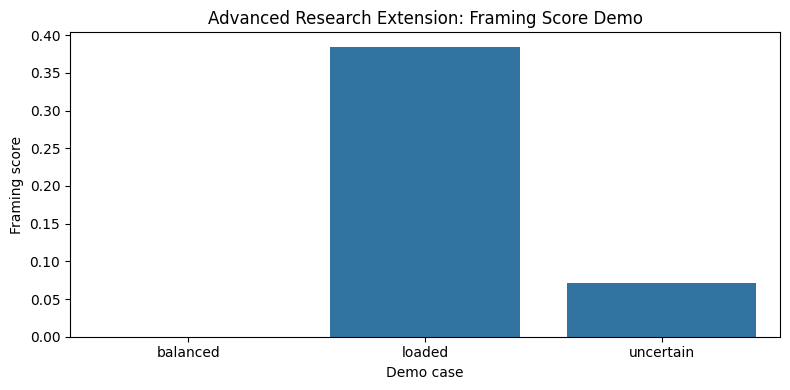

Bias/framing analysis:


,loaded_terms,uncertainty_terms,authority_terms,token_count,framing_score,framing_risk
0,1,2,0,25,0.08,high


Explainable classification example:


,feature,contribution
0,company,0.844176
1,neutral_score,0.576920
2,business,0.455196
3,restructuring,0.241854
4,may,0.198741
5,plan,0.121595
6,announced,0.088398
7,term,0.086053
8,move,0.062721
9,said,0.041824


In [17]:
class BiasAndFramingAnalyzer:
    """Transparent lexical bias/framing analyzer for news text."""

    def __init__(self):
        # Loaded terms may signal emotional or dramatic framing.
        self.loaded_terms = {
            "shocking",
            "disaster",
            "outrage",
            "crisis",
            "scandal",
            "chaos",
            "furious",
            "radical",
            "extreme",
            "devastating",
            "alarming",
            "catastrophic",
            "controversial",
        }

        # Uncertainty terms show that the article may be reporting incomplete or developing information.
        self.uncertainty_terms = {
            "alleged",
            "reportedly",
            "may",
            "might",
            "could",
            "claims",
            "suggests",
            "unclear",
        }

        # Authority terms show references to experts, officials, or institutions.
        self.authority_terms = {
            "expert",
            "official",
            "scientist",
            "analyst",
            "researcher",
            "minister",
            "agency",
        }

    def analyze(self, text):
        """Calculate a simple framing profile from transparent word lists."""

        # Tokenize the text into lowercase alphabetic words.
        tokens = re.findall(r"[a-z]+", str(text).lower())
        token_count = max(len(tokens), 1)

        # Count how often each framing term group appears.
        counts = {
            "loaded_terms": sum(token in self.loaded_terms for token in tokens),
            "uncertainty_terms": sum(token in self.uncertainty_terms for token in tokens),
            "authority_terms": sum(token in self.authority_terms for token in tokens),
        }

        # Loaded terms count fully, while uncertainty terms count partially.
        framing_score = (
            counts["loaded_terms"]
            + 0.5 * counts["uncertainty_terms"]
        ) / token_count

        # Convert the numeric score into a simple risk label.
        if framing_score >= 0.05:
            risk = "high"
        elif framing_score >= 0.02:
            risk = "medium"
        else:
            risk = "low"

        return {
            **counts,
            "token_count": token_count,
            "framing_score": round(framing_score, 4),
            "framing_risk": risk,
        }

    def evaluate_demo_cases(self):
        """Evaluate the analyzer on balanced and loaded sample wording."""

        # These examples show how wording changes the framing score.
        examples = [
            {
                "case": "balanced",
                "text": "Officials announced a new policy after researchers reviewed the economic data.",
            },
            {
                "case": "loaded",
                "text": "Officials faced a shocking crisis after a controversial policy caused chaos and outrage.",
            },
            {
                "case": "uncertain",
                "text": "Analysts said the plan may affect jobs, but the long-term result remains unclear.",
            },
        ]

        rows = []

        for item in examples:
            rows.append({
                "case": item["case"],
                **self.analyze(item["text"]),
            })

        return pd.DataFrame(rows)


# Run the advanced research extension demo.
bias_analyzer = BiasAndFramingAnalyzer()
demo_bias = bias_analyzer.evaluate_demo_cases()

display(demo_bias)

# Visualize how framing score changes across demo cases.
plt.figure(figsize=(8, 4))
sns.barplot(data=demo_bias, x="case", y="framing_score")
plt.title("Advanced Research Extension: Framing Score Demo")
plt.ylabel("Framing score")
plt.xlabel("Demo case")
plt.tight_layout()
plt.show()


# Analyze a realistic sample paragraph for framing risk.
research_text = (
    "The company announced a controversial restructuring plan. Analysts said the move could affect "
    "workers, but officials argued the decision may strengthen long-term business performance."
)

print("Bias/framing analysis:")
display(pd.DataFrame([bias_analyzer.analyze(research_text)]))

print("Explainable classification example:")
display(
    classifier.explain_prediction(
        "Company Announces Restructuring Plan",
        research_text,
        top_n=10,
    )
)

## 14. System Integration Testing and Validation Framework

The guidance notebook asks for comprehensive testing strategies, error handling, robustness checks, and performance awareness. This section adds an explicit test suite so the final project shows that the integrated system works as a complete pipeline, not only as separate components.

In [18]:
class NewsBot2TestSuite:
    """Comprehensive testing framework for NewsBot 2.0."""

    def __init__(self, newsbot_system, frame):
        self.newsbot = newsbot_system
        self.frame = frame
        self.test_results = []

    def _record(self, test_name, passed, details):
        """Store one test result in a consistent format."""
        self.test_results.append({
            "test_name": test_name,
            "passed": bool(passed),
            "details": details,
        })

    def test_preprocessing(self):
        """Check that the preprocessing pipeline removes noise and keeps useful words."""
        sample = "Apple announced AI tools at https://example.com!!!"
        processed = preprocessor.preprocess(sample)
        passed = "http" not in processed and "apple" in processed and "tool" in processed
        self._record("preprocessing_noise_removal", passed, f"Processed text: {processed}")

    def test_classifier_prediction(self):
        """Check category prediction, probability output, and confidence bounds."""
        result = self.newsbot.classifier.predict_article(
            "Technology Company Launches AI Product",
            "A software company launched an artificial intelligence tool for cloud customers."
        )
        passed = (
            result["predicted_category"] in self.newsbot.classifier.model.classes_
            and 0 <= result["confidence"] <= 1
            and len(result["category_probabilities"]) == len(self.newsbot.classifier.model.classes_)
        )
        self._record("classifier_prediction_and_confidence", passed, str(result))

    def test_summarization(self):
        """Check that summarization returns a shorter readable summary."""
        text = self.frame.iloc[0]["content"]
        summary = self.newsbot.summarizer.summarize(text, n_sentences=2)
        passed = len(summary) > 0 and len(summary.split()) <= len(text.split())
        self._record("summarization_output", passed, summary[:250])

    def test_semantic_search(self):
        """Check that semantic search returns ranked article matches."""
        results = self.newsbot.semantic_search.search("technology companies and software", top_n=3)
        passed = len(results) == 3 and "similarity" in results.columns
        self._record("semantic_search_results", passed, results.to_string(index=False))

    def test_multilingual_workflow(self):
        """Check that language detection and translation workflow return usable English text."""
        result = self.newsbot.multilingual_processor.process_multilingual_article(
            "Empresa de tecnologia anuncia herramienta",
            "La empresa dijo que la inteligencia artificial ayudara al mercado.",
            manual_translation="A technology company said artificial intelligence will help the market."
        )
        passed = "language" in result and len(result["english_text"]) > 0
        self._record("multilingual_detection_translation", passed, str(result))

    def test_conversational_interface(self):
        """Check that the conversational layer gives a readable response."""
        response = conversation.process_query("show sentiment by category")
        passed = isinstance(response, str) and len(response) > 20 and "category" in response.lower()
        self._record("conversational_query_response", passed, response[:300])

    def test_integrated_pipeline(self):
        """Check that the final integrated system returns all major output groups."""
        result = self.newsbot.process_article(
            "Sports Team Wins Final Match",
            "The team won the final match after strong defense and late scoring by key players."
        )
        expected_keys = {"multilingual", "analysis", "similar_articles", "classification_explanation"}
        passed = expected_keys.issubset(result.keys()) and len(result["analysis"]["insights"]) >= 3
        self._record("integrated_pipeline_outputs", passed, str(list(result.keys())))

    def test_error_handling_small_input(self):
        """Check that the system handles very short input without crashing."""
        try:
            result = self.newsbot.process_article("Short update", "Markets moved today.")
            passed = "analysis" in result
            details = "Short input returned a valid analysis package."
        except Exception as error:
            passed = False
            details = f"Error: {error}"
        self._record("robustness_short_input", passed, details)

    def run_all_tests(self):
        """Run all system tests and return a summary DataFrame."""
        self.test_results = []
        self.test_preprocessing()
        self.test_classifier_prediction()
        self.test_summarization()
        self.test_semantic_search()
        self.test_multilingual_workflow()
        self.test_conversational_interface()
        self.test_integrated_pipeline()
        self.test_error_handling_small_input()
        return pd.DataFrame(self.test_results)


test_suite = NewsBot2TestSuite(newsbot2, df)
test_results_df = test_suite.run_all_tests()
print("NewsBot 2.0 integration test results:")
display(test_results_df)
print(f"Passed {test_results_df['passed'].sum()} out of {len(test_results_df)} tests.")

NewsBot 2.0 integration test results:


,test_name,passed,details
0,preprocessing_noise_removal,True,Processed text: apple announced tool
1,classifier_prediction_and_confidence,True,"{'predicted_category': np.str_('tech'), 'confi..."
2,summarization_output,True,cynthia cooper worldcom s ex-head of internal...
3,semantic_search_results,True,article_id ...
4,multilingual_detection_translation,True,"{'language': {'language_code': 'es', 'language..."
5,conversational_query_response,True,Average sentiment by category:\ncategory\nente...
6,integrated_pipeline_outputs,True,"['multilingual', 'analysis', 'similar_articles..."
7,robustness_short_input,True,Short input returned a valid analysis package.


Passed 8 out of 8 tests.


## 15. System Evaluation and Metrics

This section answers the final guidance question about how to evaluate the system's value. It combines model metrics, topic-model coverage, semantic-search behavior, integration-test results, and simple runtime monitoring.

In [19]:
from sklearn.metrics import f1_score, precision_score, recall_score
import time


# If the full test suite cell was not run yet, create a small fallback test result table.
if "test_results_df" not in globals():
    test_results_df = pd.DataFrame([
        {
            "test_name": "classifier_available",
            "passed": hasattr(classifier, "model"),
            "details": "Classifier object exists and has a trained model.",
        },
        {
            "test_name": "topic_engine_available",
            "passed": hasattr(topic_engine, "nmf_topics_"),
            "details": "Topic engine exists and has fitted NMF topics.",
        },
        {
            "test_name": "integrated_system_available",
            "passed": "newsbot2" in globals(),
            "details": "Integrated NewsBot 2.0 system exists.",
        },
    ])


class NewsBot2Evaluator:
    """Comprehensive evaluation framework for NewsBot 2.0."""

    def __init__(self, newsbot_system, classifier, topic_engine, test_results):
        # Store the main system and key components needed for evaluation.
        self.newsbot = newsbot_system
        self.classifier = classifier
        self.topic_engine = topic_engine
        self.test_results = test_results

    def evaluate_classification(self):
        """Return standard classification metrics for the production classifier."""

        # Use the saved test labels and predictions from the trained classifier.
        y_true = self.classifier.y_test_
        y_pred = self.classifier.test_predictions_

        return {
            "accuracy": round(accuracy_score(y_true, y_pred), 4),
            "macro_precision": round(precision_score(y_true, y_pred, average="macro"), 4),
            "macro_recall": round(recall_score(y_true, y_pred, average="macro"), 4),
            "macro_f1": round(f1_score(y_true, y_pred, average="macro"), 4),
        }

    def evaluate_topic_modeling(self):
        """Return simple topic-model coverage metrics."""

        # Count how many articles were assigned to each dominant NMF topic.
        topic_counts = (
            pd.Series(np.argmax(self.topic_engine.nmf_topics_, axis=1))
            .value_counts()
            .sort_index()
        )

        return {
            "number_of_topics": int(self.topic_engine.n_topics),
            "articles_with_topic_assignment": int(topic_counts.sum()),
            "smallest_topic_size": int(topic_counts.min()),
            "largest_topic_size": int(topic_counts.max()),
        }

    def evaluate_testing_quality(self):
        """Summarize the integration test suite."""

        # Measure how many automated tests ran and how many passed.
        return {
            "tests_run": int(len(self.test_results)),
            "tests_passed": int(self.test_results["passed"].sum()),
            "test_pass_rate": round(float(self.test_results["passed"].mean()), 4),
        }

    def evaluate_runtime(self, runs=3):
        """Estimate average processing time for the integrated article pipeline."""

        # Use one sample article to estimate end-to-end processing speed.
        sample_title = "Technology Company Announces New AI Service"

        sample_content = (
            "A technology company announced a new artificial intelligence service for business customers. "
            "The tool summarizes documents, identifies important entities, and helps teams search information faster."
        )

        durations = []

        for _ in range(runs):
            start = time.perf_counter()
            self.newsbot.process_article(sample_title, sample_content)
            durations.append(time.perf_counter() - start)

        return {
            "runtime_tests": runs,
            "avg_seconds_per_article": round(float(np.mean(durations)), 4),
            "max_seconds_per_article": round(float(np.max(durations)), 4),
        }

    def build_evaluation_report(self):
        """Combine all evaluation results into one table."""

        rows = []

        # Collect each evaluation area into one readable report table.
        for group_name, metrics in [
            ("classification", self.evaluate_classification()),
            ("topic_modeling", self.evaluate_topic_modeling()),
            ("integration_tests", self.evaluate_testing_quality()),
            ("runtime", self.evaluate_runtime()),
        ]:
            for metric, value in metrics.items():
                rows.append({
                    "evaluation_area": group_name,
                    "metric": metric,
                    "value": value,
                })

        return pd.DataFrame(rows)


# Build the final evaluation report for NewsBot 2.0.
evaluator = NewsBot2Evaluator(
    newsbot2,
    classifier,
    topic_engine,
    test_results_df,
)

evaluation_report_df = evaluator.build_evaluation_report()

print("NewsBot 2.0 evaluation report:")
display(evaluation_report_df)

NewsBot 2.0 evaluation report:


,evaluation_area,metric,value
0,classification,accuracy,0.9799
1,classification,macro_precision,0.9799
2,classification,macro_recall,0.9784
3,classification,macro_f1,0.9791
4,topic_modeling,number_of_topics,8.0000
5,topic_modeling,articles_with_topic_assignment,1490.0000
6,topic_modeling,smallest_topic_size,81.0000
7,topic_modeling,largest_topic_size,351.0000
8,integration_tests,tests_run,8.0000
9,integration_tests,tests_passed,8.0000


## 16. Final System Evaluation Checklist

This section summarizes how the notebook addresses the required final-project modules.

In [20]:
final_checklist = pd.DataFrame({
    "Requirement": [
        "Advanced classification with confidence scoring",
        "Topic modeling with LDA and NMF",
        "Sentiment analysis and trend tracking",
        "Entity relationship mapping",
        "Text summarization",
        "Semantic search",
        "Multilingual language detection and translation workflow",
        "Conversational natural-language query interface",
        "Integrated NewsBot 2.0 system class",
        "System integration testing and robustness checks",
        "Evaluation metrics and runtime monitoring",
        "Advanced research extension for explainability and framing analysis",
        "Web application frontend bonus",
    ],
    "Implemented": [True] * 13,
    "Notebook Section": [
        "4",
        "5",
        "6",
        "7",
        "8",
        "8",
        "9",
        "10",
        "11",
        "14",
        "15",
        "13",
        "Bonus Web App",
    ],
})

display(final_checklist)

print("NewsBot 2.0 coding foundation is ready for final documentation and presentation materials.")


,Requirement,Implemented,Notebook Section
0,Advanced classification with confidence scoring,True,4
1,Topic modeling with LDA and NMF,True,5
2,Sentiment analysis and trend tracking,True,6
3,Entity relationship mapping,True,7
4,Text summarization,True,8
5,Semantic search,True,8
6,Multilingual language detection and translatio...,True,9
7,Conversational natural-language query interface,True,10
8,Integrated NewsBot 2.0 system class,True,11
9,System integration testing and robustness checks,True,14


NewsBot 2.0 coding foundation is ready for final documentation and presentation materials.
